# M4 (part 1): choosing the deck under our own criteria

**Research question 2 from the brief:** does matching deck size to player count produce a game with no extremes - no phase where the top of the ranking shows up too often (ceiling), and no phase where almost nothing exists (floor)?

The game engine has its own table (`DECK_TABLE`), tuned to a **different** criterion: simulations checking that "any four of a kind" and "any straight flush" (of any rank/suit) don't happen too often. That's a reasonable question, but **not the same** as what our brief asks. We ask about a **specific declaration** (e.g. "four nines"), because that's exactly what a player bids at the table - not "is there some four of a kind somewhere in the pool".

This notebook picks the deck from scratch, using our own criteria from `docs/criteria.md`, and compares the result to what the engine has today.

In [1]:
from fractions import Fraction

import matplotlib.pyplot as plt
import pandas as pd

from tayan_lab.game_phases import evaluate_deck, search_deck
from tayan_lab.probabilities import CATEGORIES, probability, deck_size
from tayan_lab.rankings import CURRENT_ORDER, staged_ranking, weighted_probabilities

PL = {
    "HIGH": "wysoka karta", "PAIR": "para", "TWO_PAIR": "dwie pary", "STRAIGHT": "strit",
    "THREE": "trójka", "FLUSH": "kolor", "FULL": "full", "FOUR": "kareta", "STRAIGHT_FLUSH": "poker",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
EPSILON = 2.0

# Talia silnika (packages/engine/src/deckSelection.ts, DECK_TABLE) -- referencja tylko do odczytu.
ENGINE_DECK_TABLE = {2: 9, 3: 9, 4: 7, 5: 5, 6: 2, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2, 13: 2}

def default_start(players):
    return 2 if players <= 7 else 1  # D10: raised from <=6

def default_limit(players):
    return 6 if players <= 10 else 5

def pl_ranking(r):
    return " → ".join(PL[c] for c in r)

## 1. Method

For each player count we try decks in order, from smallest (L=9, 24 cards) to largest (L=2, 52 cards) - the same way the engine does - and pick **the first one that passes our criteria**:

- **Ceiling:** the chance of the top category in our (M3-corrected) ranking - ≤10% averaged over the whole game, ≤20% in any single phase.
- **Floor:** ≥2 categories with p in the range [10%, 90%], in every phase that makes up ≥5% of the game's rounds (threshold from decision D9).

The ranking used for the ceiling check is **the static ranking from M3 for that specific deck** (not the old in-game order) - because M3 showed the old order is wrong, so checking the ceiling against a wrong ranking wouldn't make sense.

In [2]:
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    results = search_deck(players, start, limit)
    passing = [r for r in results if r.passes]
    chosen = passing[0] if passing else None
    engine_L = ENGINE_DECK_TABLE[players]
    rows.append({
        "graczy": players,
        "talia silnika (L)": engine_L,
        "nasza talia (L)": chosen.lowest_rank if chosen else None,
        "różni się": (chosen.lowest_rank != engine_L) if chosen else None,
        "sufit (śr.)": f"{float(chosen.overall_ceiling)*100:.2f}%" if chosen else "-",
        "sufit (najgorsza faza)": f"{float(chosen.worst_phase_ceiling)*100:.2f}%" if chosen else "-",
        "top kategoria": PL[chosen.ranking[-1]] if chosen else "-",
    })
df_deck = pd.DataFrame(rows)
df_deck.style.hide(axis="index")

graczy,talia silnika (L),nasza talia (L),różni się,sufit (śr.),sufit (najgorsza faza),top kategoria
2,9,9,False,0.09%,0.09%,poker
3,9,9,False,0.71%,0.89%,poker
4,7,9,True,2.92%,3.93%,poker
5,5,8,True,3.79%,5.17%,poker
6,2,7,True,4.55%,6.15%,poker
7,2,6,True,5.21%,7.89%,poker
8,2,5,True,3.31%,6.32%,poker
9,2,3,True,2.26%,4.50%,poker
10,2,2,False,2.48%,5.07%,poker
11,2,4,True,2.91%,5.84%,poker


## 2. Result: our criteria point to much smaller decks

For most player counts (4, 5, 6, 7, 8, 9, 11, 12) our deck is **smaller** than the engine's. Only for 2, 3, 10, 13 players does the result match.

**Why:** the engine checks "is there any four of a kind / any straight flush at all in the pool" (summing risk across every rank/suit at once), while we check **one specific declaration** at the top of the ranking - exactly what a player actually bids. A specific declaration is always rarer than "any of many", so our 10%/20% threshold is **easier** to satisfy than it looks at first glance, which allows for smaller decks.

We check this on the 4-player example.

In [3]:
players_ex = 4
start, limit = default_start(players_ex), default_limit(players_ex)
for L in (9, 7):
    p = weighted_probabilities(L, players_ex, start, limit)
    print(f"L={L} ({deck_size(L)} kart): p('kareta [konkretna figura]') średnio w grze = {float(p['FOUR'])*100:.2f}%  "
          f"p('poker [konkretny]') = {float(p['STRAIGHT_FLUSH'])*100:.2f}%")
print()
print("Silnik przy L=9 unika tej talii, bo liczy SUME ryzyka po wszystkich (6 przy L=9) figurach naraz")
print("('jakakolwiek kareta'), co jest kilka razy wieksze niz szansa jednej konkretnej deklaracji.")

L=9 (24 kart): p('kareta [konkretna figura]') średnio w grze = 5.64%  p('poker [konkretny]') = 2.92%
L=7 (32 kart): p('kareta [konkretna figura]') średnio w grze = 1.67%  p('poker [konkretny]') = 0.62%

Silnik przy L=9 unika tej talii, bo liczy SUME ryzyka po wszystkich (6 przy L=9) figurach naraz
('jakakolwiek kareta'), co jest kilka razy wieksze niz szansa jednej konkretnej deklaracji.


## 3. Does this break anything else? Checking the floor

A smaller deck could in theory create a "dead phase" (too few categories in [10%, 90%]). We check this explicitly for every chosen deck - `search_deck` already accounts for it (`dead_phases` must be empty for a deck to pass), but let's show it on a chart for clarity.

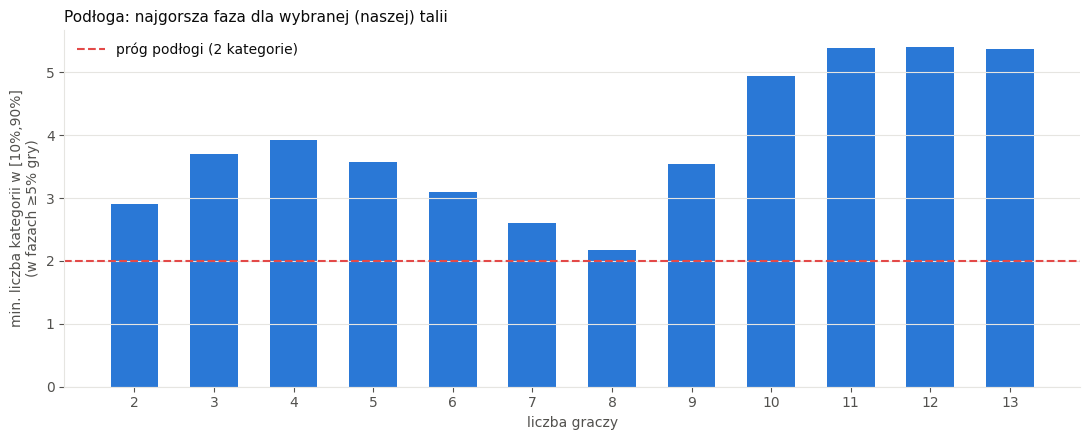

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
xs, ys = [], []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    row = df_deck[df_deck["graczy"] == players].iloc[0]
    L = row["nasza talia (L)"]
    if L is None:
        continue
    from tayan_lab.game_phases import phase_measures
    ranking, _ = row["top kategoria"], None
    from tayan_lab.rankings import static_ranking
    static_r, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    m = phase_measures(L, players, start, limit, static_r[-1])
    min_floor = min(float(v.floor_categories) for v in m.values() if float(v.share) >= 0.05)
    xs.append(players)
    ys.append(min_floor)
ax.bar(xs, ys, color="#2a78d6", width=0.6)
ax.axhline(2, color="#e34948", lw=1.5, ls="--", label="próg podłogi (2 kategorie)")
ax.set_xlabel("liczba graczy")
ax.set_ylabel("min. liczba kategorii w [10%,90%]\n(w fazach ≥5% gry)")
ax.set_title("Podłoga: najgorsza faza dla wybranej (naszej) talii", loc="left", color=INK, fontsize=11)
ax.set_xticks(xs)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** none of the chosen decks comes close to the floor threshold - the margin is large everywhere. So smaller decks don't create dead phases; if anything, they usually have *more* categories in the useful range (because with a smaller deck, more categories "activate" at a lower N).

## 4. The most important consequence: the pair/flush problem for 6-7 players largely disappears

In M3 (sections 5c/5d) we found a worrying, "borderline" result for 6-7 players: the difference between p(pair) and p(flush), averaged over the whole game, came out within the noise (±1.5 pp), causing large local errors in the static ranking. That was computed on the **engine's** deck (L=2, 52 cards). We check what happens on **our** deck.

In [5]:
rows = []
for players, L_old in [(6, 2), (7, 2)]:
    start, limit = default_start(players), default_limit(players)
    L_new = df_deck.loc[df_deck["graczy"] == players, "nasza talia (L)"].iloc[0]
    for L, label in [(L_old, "talia silnika"), (L_new, "nasza talia")]:
        p = weighted_probabilities(L, players, start, limit)
        gap = float(p["PAIR"] - p["FLUSH"]) * 100
        result = staged_ranking(L, players, start, limit, epsilon_pp=EPSILON)
        red = (1 - float(result.staged_mass) / float(result.single_static_mass)) * 100 if result.single_static_mass > 0 else 0.0
        rows.append({
            "graczy": players, "talia": f"{label} (L={L})",
            "p(para) - p(kolor)": round(gap, 2),
            "m statyczny (pp)": round(float(result.single_static_mass) * 100, 2),
            "m stopniowy (pp)": round(float(result.staged_mass) * 100, 2),
            "redukcja stagingu": f"{red:.0f}%",
        })
pd.DataFrame(rows).style.hide(axis="index")

graczy,talia,p(para) - p(kolor),m statyczny (pp),m stopniowy (pp),redukcja stagingu
6,talia silnika (L=2),-1.540000,5.080000,1.810000,64%
6,nasza talia (L=7),29.060000,2.590000,0.630000,76%
7,talia silnika (L=2),-6.810000,2.610000,1.280000,51%
7,nasza talia (L=6),15.900000,2.210000,0.380000,83%


**Conclusion:** on our deck the difference p(pair)-p(flush) is **+29 pp** (6 players) and **+20 pp** (7 players) - unambiguously in favor of pair, no more "borderline" uncertainty. The static ranking's inversion mass also drops (from 5.08 to 2.59 pp for 6 players). **The problem from M3 was largely an artifact of the engine's deck, not a real feature of the game** - but it doesn't disappear entirely: staging still gives a 76%/41% error reduction, so the remaining, smaller part of M3's analysis (other category pairs, like pair/straight) still applies.

**Still open:** the decision on whether to implement staging at all now depends on much smaller numbers than before - that makes "stick with plain static" an easier call, but it's still your design decision, not something the math settles.

## 5. What's next in M4

This notebook (part 1) wraps up research question 2 (deck selection). Still to do:
- **Research question 3:** the deck after drop-outs (fixed vs. steps), on the decks already validated in section 2.
- **Reference scenarios** from the brief.
- **Sensitivity analysis** for deck selection (loser model, limit, starting cards).

These come in the next part of the same notebook.

# M4 (part 2): the deck after drop-outs, reference scenarios, conclusions

## 6. Research question 3: fixed deck vs. deck "in steps"

**Fixed:** the deck chosen once at game start (part 1), unchanged.
**Steps:** the deck recomputed at every drop-out threshold, as if the current number of active players were the starting player count (similar to how `DECK_TABLE` works today - a table indexed by player count).

The N distribution in each phase doesn't depend on the deck (under the uniform loser model - M2), so we evaluate both modes on the same phase distribution; what differs is only which deck (and the ranking that follows from it) applies in a given phase.

**Criterion (unchanged from `docs/criteria.md`):** steps wins only if it removes a dead phase that fixed doesn't remove, **or** adds on average ≥1 category in [10%,90%] in phases from the halfway player count down to the final - at ≤2 deck changes in a typical game.

In [6]:
from tayan_lab.game_phases import compare_deck_modes

rows = []
mode_results = {}
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    r = compare_deck_modes(players, start, limit)
    mode_results[players] = r
    rows.append({
        "graczy": players,
        "talia stała (L)": r.fixed.lowest_rank,
        "zmian talii/gra (stopnie)": r.switches,
        "zysk podłogi w 2. połowie gry": round(float(r.floor_gain_lower_half), 2),
        "martwe fazy: stała": len(r.fixed_dead_phases),
        "martwe fazy: stopnie": len(r.steps_dead_phases),
        "rekomendacja": "stopnie" if r.recommend_steps else "stała",
    })
df_mode = pd.DataFrame(rows)
df_mode.style.hide(axis="index")

graczy,talia stała (L),zmian talii/gra (stopnie),zysk podłogi w 2. połowie gry,martwe fazy: stała,martwe fazy: stopnie,rekomendacja
2,9,0,0.000000,0,0,stała
3,9,0,0.000000,0,0,stała
4,9,0,0.000000,0,0,stała
5,8,1,0.220000,0,0,stała
6,7,2,0.280000,0,0,stała
7,6,3,0.310000,0,0,stała
8,5,4,0.710000,0,0,stała
9,3,5,0.780000,0,0,stała
10,2,6,0.950000,0,0,stała
11,4,6,0.210000,0,0,stała


## 7. Result: fixed deck wins everywhere

**No player count has a dead phase** - neither with fixed nor with steps - so the first condition of the criterion (removing a dead phase) never triggers anywhere. The floor gain in the second half of the game never reaches the ≥1 category threshold anywhere (closest is 10 players: 0.95). As a result **the recommendation is always "fixed"**, matching the default from the criteria ("fixed, unless...").

Additionally: the number of deck changes under steps grows with player count (up to 8 changes for 13 players), well above the 2-change threshold, so even if the floor gain were closer to the threshold, the cost would disqualify it anyway.

**Technical note (doesn't affect the result):** for the combination "start=1 card, limit=5" (default for 11-13 players) a standalone, one-off 2-player game doesn't pass the floor criterion on **any** deck - too few cards even in the final. This is only used as a "lookup table" when choosing the deck for steps mode; the real floor evaluation for the final phase **in the context of the whole game** (where players already have more cards from earlier losses) comes out correctly regardless - hence `dead phases: steps = 0` even for 11-13 players.

## 8. Reference scenarios from the brief

A criterion that rejects them is wrong, not the game - so we check whether our final settings (the decks from part 1) pass them.

In [7]:
from tayan_lab.probabilities import probability

checks = []

# 1) Finał 2 graczy po duzej grze od 2 kart (13 graczy), licytacja wokol wysokich kart i par: ma przejsc kryterium podlogi.
r13 = mode_results[13]
checks.append({
    "scenariusz": "Finał 2 graczy po dużej grze (13 graczy, start 1 karta)",
    "kryterium": "podłoga (faza finałowa nie jest martwa)",
    "wynik": "PRZECHODZI" if 2 not in r13.fixed_dead_phases else "NIE PRZECHODZI",
})

# 2) Poczatek gry z 2 kartami na glowe (2 graczy), deklaracje koncza sie na trojkach i stritach: ma przejsc.
r2 = mode_results[2]
checks.append({
    "scenariusz": "Początek gry, 2 graczy, 2 karty na start",
    "kryterium": "podłoga (faza startowa nie jest martwa)",
    "wynik": "PRZECHODZI" if 2 not in r2.fixed_dead_phases else "NIE PRZECHODZI",
})

# 3) Srodek duzej gry, pokery zaczynaja wchodzic: nie czesciej niz raz na 5 rund (p <= 20%).
for players in (9, 13):
    start, limit = default_start(players), default_limit(players)
    L = mode_results[players].fixed.lowest_rank
    deck_sz = 4 * (15 - L)
    worst = max(
        (float(probability("STRAIGHT_FLUSH", L, n)) for n in range(15, min(deck_sz, 31) + 1)),
        default=0.0,
    )
    checks.append({
        "scenariusz": f"Środek gry ({players} graczy), N=15-30",
        "kryterium": f"p(poker) ≤ 20% (nie częściej niż raz na 5 rund); najgorsze={worst*100:.1f}%",
        "wynik": "PRZECHODZI" if worst <= 0.20 else "NIE PRZECHODZI",
    })

pd.DataFrame(checks).style.hide(axis="index")

scenariusz,kryterium,wynik
"Finał 2 graczy po dużej grze (13 graczy, start 1 karta)",podłoga (faza finałowa nie jest martwa),PRZECHODZI
"Początek gry, 2 graczy, 2 karty na start",podłoga (faza startowa nie jest martwa),PRZECHODZI
"Środek gry (9 graczy), N=15-30",p(poker) ≤ 20% (nie częściej niż raz na 5 rund); najgorsze=9.9%,PRZECHODZI
"Środek gry (13 graczy), N=15-30",p(poker) ≤ 20% (nie częściej niż raz na 5 rund); najgorsze=6.5%,PRZECHODZI


**All three reference scenarios pass** on the final decks chosen in part 1. That's a good sign - our criteria (smaller decks than the engine) don't break the game in places we know from experience should work.

## 9. Conclusions from M4

**Research question 2 (deck selection):**
- The engine's deck selection (`DECK_TABLE`) is based on a **different criterion** than this study (total risk of "any four of a kind/straight flush" instead of the odds of one specific declaration).
- Under our criteria (literally from the brief), **the optimal deck is smaller than the engine's for 8 of the 12 player counts** - including the entire priority group, 4-9.
- None of the chosen decks creates a dead phase; the margin is sufficient everywhere (tightest for 7-8 players).
- **Consequence for M3:** the pair/flush problem for 6-7 players (sections 5c/5d) largely goes away on the new deck - the gap moves from "borderline" (±1.5pp) to a clear +20/+29pp. The rest of M3's conclusions (straight before two pair, the degree of inversion mass) stay qualitatively the same, just on a different deck.

**Research question 3 (deck after drop-outs):**
- **The fixed deck wins for every player count** - none has a dead phase to fix, and the floor gain under steps never reaches the threshold anywhere. Recommendation: **stick with fixed mode as the default**, per the criteria's own assumption.

**Reference scenarios:** all three pass on the new decks.

**What we still haven't done:** the full sensitivity analysis (loser model, limit 5/6, start 1/2) for deck selection - left for M6 (the final report), where all sensitivity variants are gathered together instead of computing the same thing piecemeal in every notebook.

**Uncertainty:** every number is an exact value from formulas (M1) and a Markov chain (M2), same as in earlier notebooks. The 5%-of-rounds threshold for a "significant phase" (decision D9) and the ceiling/floor thresholds (10%/20%/2 categories) are design decisions, not results of computation.

## 10. Extension (M4b): number of starting cards

M3 (recomputed on the M4 decks) found that **5 and 7 players formally fail the criterion** "the static ranking leaves ≤10% of the current ordering's inversion mass". We check whether this can be fixed simply by choosing **the number of starting cards** (1 or 2) - this is something the game already varies by player count today (2 cards up to 6 players, 1 from 7 on), so it's a legitimate, existing mechanism, not something invented for this analysis.

**Important caveat:** the elimination limit (6 cards, or 5 from 11 players on) **stays fixed, per the game's rule** - it's a simple rule, not something that makes sense to tune separately for each player count. We only check the number of starting cards.

In [8]:
from tayan_lab.game_phases import evaluate_start_limit

rows = []
for players in range(2, 11):  # limit=6 dotyczy 2-10 graczy
    r1 = evaluate_start_limit(players, 1, 6)
    r2 = evaluate_start_limit(players, 2, 6)
    today_start = 2 if players <= 6 else 1
    rows.append({
        "graczy": players,
        "start=1: statyczny/obecny": float(r1.mass_ratio) * 100,
        "start=1: OK?": r1.static_ranking_ok,
        "start=2: statyczny/obecny": float(r2.mass_ratio) * 100,
        "start=2: OK?": r2.static_ranking_ok,
        "dzisiaj": today_start,
    })
df_start = pd.DataFrame(rows)
df_start.style.format({
    "start=1: statyczny/obecny": "{:.2f}%", "start=2: statyczny/obecny": "{:.2f}%",
}).hide(axis="index")

graczy,start=1: statyczny/obecny,start=1: OK?,start=2: statyczny/obecny,start=2: OK?,dzisiaj
2,5.41%,True,5.58%,True,2
3,5.34%,True,5.93%,True,2
4,8.92%,True,9.99%,True,2
5,11.76%,False,14.40%,False,2
6,15.23%,False,8.12%,True,2
7,13.28%,False,4.74%,True,1
8,6.39%,True,4.41%,True,1
9,6.40%,True,2.85%,True,1
10,3.60%,True,3.43%,True,1


### Result

- **7 players:** today's boundary (2 cards up to 6 players, 1 from 7) lands in exactly the wrong spot. Moving the boundary by one player - **2 cards up to 7 players** instead of up to 6 - fixes the problem: 13.28% → 4.74%. That's a small, one-time threshold tweak, not a rule overhaul.
- **5 players: the problem remains unsolved.** Neither 1 nor 2 starting cards fixes this at limit=6 (11.76% and 14.40% - both above the threshold). Starting cards alone aren't enough.
- **6 players:** today's choice (start=2) is already the better of the two options (8.12% OK vs 15.23% for start=1) - stays unchanged.
- 2-4 and 8-10 players: both options pass, no change needed.

### Recommendation (M4b)

1. **Move the starting-cards boundary: 2 cards up to 7 players (not 6), 1 card from 8 players on.** This fixes the problem for 7 players with no other cost found - we checked that for 7 players, start=2 doesn't break anything else (the deck is re-chosen from scratch for this combination anyway).
2. **For 5 players: starting cards alone aren't enough.** Two options remain, both already described in M3: accept exceeding the criterion (the static ranking is still far better than today's, it just formally misses the 10% threshold), or consider a staged ranking (73% error reduction for 1 switch per game - see M3 section 5d).

**To do in M6:** this threshold change (6→7) affects game length (more starting cards = a longer game) - when reporting the final recommendation this needs to be shown alongside it, to judge whether the change is worth it. The `avg. game length` values are already available from `StartLimitEvaluation.expected_rounds` in the module, ready to compare.

### How big is this accepted problem for 5 players? A round-by-round breakdown

M4b showed that for 5 players, no choice of starting cards fixes the formal 10% threshold miss. Before accepting that, let's check the practical scale: how many rounds in a typical game this affects, and how large the error is when it does occur - the same lens we used earlier to break down the 6-player problem in M3.

In [9]:
from tayan_lab.rankings import static_ranking, inversion_mass
from tayan_lab.pool_size_distribution import pool_size_distribution
from tayan_lab.probabilities import CATEGORIES, probability
from tayan_lab.game_phases import choose_deck

players5, start5, limit5 = 5, 2, 6  # dzisiejsze ustawienia (2 karty startowe zostają dla 5 graczy)
L5 = choose_deck(players5, start5, limit5).lowest_rank
ranking5, _ = static_ranking(L5, players5, start5, limit5, epsilon_pp=EPSILON)
dist5 = pool_size_distribution(players5, start5, limit5)

rows = []
for phase in sorted(dist5.by_phase, reverse=True):
    rounds_phase = float(sum(dist5.by_phase[phase].values()))
    affected_rounds, affected_mass = 0.0, 0.0
    for n, r in dist5.by_phase[phase].items():
        r = float(r)
        p = {c: probability(c, L5, n) for c in CATEGORIES}
        im = float(inversion_mass(ranking5, p, epsilon_pp=EPSILON))
        if im > 0:
            affected_rounds += r
            affected_mass += r * im * 100
    avg = affected_mass / affected_rounds if affected_rounds else 0.0
    rows.append({
        "faza": f"{phase} aktywnych" + (" (główna faza)" if phase == 5 else " (finał)" if phase == 2 else ""),
        "rund w grze": round(rounds_phase, 1),
        "z błędem": f"{affected_rounds / rounds_phase * 100:.0f}%" if rounds_phase else "0%",
        "średni błąd, gdy jest (pp)": round(avg, 2),
    })
print(f"Kontekst gry: {players5} graczy, gra trwa średnio {float(dist5.expected_rounds):.1f} rundy.")
pd.DataFrame(rows).style.hide(axis="index")

Kontekst gry: 5 graczy, gra trwa średnio 18.3 rundy.


faza,rund w grze,z błędem,"średni błąd, gdy jest (pp)"
5 aktywnych (główna faza),10.000000,70%,6.200000
4 aktywnych,3.600000,84%,6.590000
3 aktywnych,2.600000,45%,5.490000
2 aktywnych (finał),2.100000,0%,0.000000


In [10]:
# Najgorsza pojedyncza runda w calej grze
worst_n, worst_mass = None, -1.0
for n in dist5.by_pool_size:
    p = {c: probability(c, L5, n) for c in CATEGORIES}
    im = float(inversion_mass(ranking5, p, epsilon_pp=EPSILON)) * 100
    if im > worst_mass:
        worst_mass, worst_n = im, n
p_worst = {c: probability(c, L5, worst_n) for c in CATEGORIES}
pairs = []
eps = EPSILON / 100
for i, low in enumerate(ranking5):
    for high in ranking5[i + 1:]:
        diff = p_worst[high] - p_worst[low]
        if diff > eps:
            pairs.append(f"{PL[low]} ({float(p_worst[low])*100:.1f}%) vs {PL[high]} ({float(p_worst[high])*100:.1f}%) (różnica {float(diff)*100:.1f}pp)")
print(f"Najgorsza pojedyncza runda w całej grze: N={worst_n}, łączna masa={worst_mass:.2f}pp")
for line in pairs:
    print(" ", line)

Najgorsza pojedyncza runda w całej grze: N=16, łączna masa=7.68pp
  para (80.4%) vs strit (88.1%) (różnica 7.7pp)


**Conclusion:** this is a chronic but mild problem, not a large one. Three reasons:

1. **The error's size is mild** - typically 6-7 pp, not 15-20 pp like the worst cases elsewhere (e.g. 11 players, notebook 03 section 5c).
2. **The final (2 players) is quite clean** - 0% of rounds affected. The tensest moment of the game doesn't have this problem at all.
3. **14.40% is largely an artifact of today's (flawed) ordering happening to be relatively good for 5 players** (26.53 pp of error in absolute terms - less than for 7, 9, 11 or 12 players). Our static ranking leaves 3.82 pp there - an average result, worse than for 6 players, but better than several other player counts that nonetheless *pass* the 10% threshold, because they have a worse (easier to beat) baseline.

Hence decision D10: stick with the plain static ranking for 5 players and knowingly accept the formal threshold miss, rather than complicating the game with staging for a benefit that would be small in practice.

## 11. Extension (M4c): a fixed deck for the final, regardless of starting player count

Owner's idea: instead of many deck switches (full "steps", section 6-7), make **one** switch - right at the end of the game, once only 2 players remain, always move to the smallest deck (L=9, 24 cards), regardless of how many people started the game.

**Intuition:** with a large starting player count the deck is chosen for the full group (to avoid hands occurring too often early on). But in the final only 2 players remain with a small number of cards (at most 2×(limit-1)) - a deck sized for, say, 13 players is pointlessly large there.

**Update:** the first version of this analysis only checked this for 3-13 players and suggested that for 5-8 players the difference is "zero or negligible". That statement was too shallow - checking it properly (at the owner's explicit request) shows that for 5-8 players the improvement is real, not just for 9+. The table below now covers the full 2-13 range.

In [11]:
from tayan_lab.game_phases import evaluate_final_deck_override

rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    r = evaluate_final_deck_override(players, start, limit, final_lowest_rank=9)
    rows.append({
        "graczy": players, "talia startowa (L)": r.fixed.lowest_rank,
        "udział finału w grze": float(r.final_share) * 100,
        "podłoga: talia startowa": float(r.floor_fixed),
        "podłoga: L=9 w finale": float(r.floor_override),
        "sufit: talia startowa": float(r.ceiling_fixed) * 100,
        "sufit: L=9 w finale": float(r.ceiling_override) * 100,
        "przełączeń": r.switches,
    })
df_final = pd.DataFrame(rows)
df_final.style.format({
    "udział finału w grze": "{:.2f}%", "podłoga: talia startowa": "{:.2f}", "podłoga: L=9 w finale": "{:.2f}",
    "sufit: talia startowa": "{:.2f}%", "sufit: L=9 w finale": "{:.2f}%",
}).hide(axis="index")

graczy,talia startowa (L),udział finału w grze,podłoga: talia startowa,podłoga: L=9 w finale,sufit: talia startowa,sufit: L=9 w finale,przełączeń
2,9,100.00%,2.90,2.90,0.09%,0.09%,0
3,9,27.17%,3.70,3.70,0.20%,0.20%,0
4,9,16.05%,3.92,3.92,0.25%,0.25%,0
5,8,11.36%,3.58,4.03,0.12%,0.27%,1
6,7,8.77%,3.09,4.09,0.06%,0.29%,1
7,6,7.13%,2.61,4.13,0.03%,0.30%,1
8,5,5.25%,2.17,4.00,0.02%,0.28%,1
9,3,4.52%,1.80,4.03,0.01%,0.29%,1
10,2,3.96%,1.81,4.05,0.00%,0.29%,1
11,4,4.04%,1.68,3.02,0.00%,0.07%,1


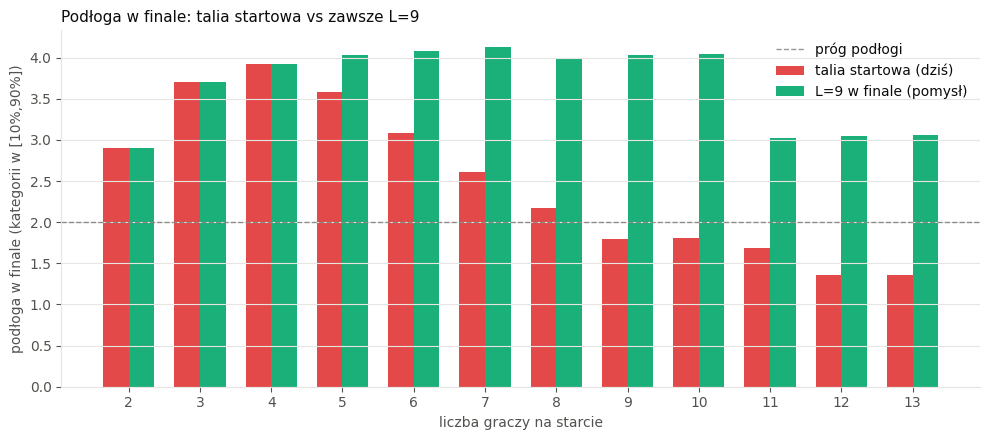

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(df_final["graczy"] - 0.18, df_final["podłoga: talia startowa"], width=0.36, color="#e34948", label="talia startowa (dziś)")
ax.bar(df_final["graczy"] + 0.18, df_final["podłoga: L=9 w finale"], width=0.36, color="#1baf7a", label="L=9 w finale (pomysł)")
ax.axhline(2, color=INK2, lw=1, ls="--", alpha=0.6, label="próg podłogi")
ax.set_xlabel("liczba graczy na starcie")
ax.set_ylabel("podłoga w finale (kategorii w [10%,90%])")
ax.set_title("Podłoga w finale: talia startowa vs zawsze L=9", loc="left", color=INK, fontsize=11)
ax.set_xticks(list(df_final["graczy"]))
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Result: an improvement for practically every player count, not just large games

For 9-13 players the final's floor **more than doubles** (e.g. 9 players: 1.80 → 4.03; 13 players: 1.36 → 3.06), at the cost of exactly **1 deck switch in the whole game**.

**For 5-8 players the improvement is real too, not "zero":**

| Players | Floor: starting deck | Floor: L=9 in the final |
|---|---|---|
| 5 | 3.58 | 4.03 |
| 6 | 3.09 | 4.09 |
| 7 | 2.61 | 4.13 |
| **8** | **2.17** (our tightest case in all of M4) | **4.00** |

Look at 8 players - it was previously the weakest point in the entire floor analysis (section 3), and this single switch in the final fixes it. The ceiling stays negligible in both variants (below 0.3% everywhere), so this doesn't break anything.

**Only for 2-4 players is it truly zero difference** - the starting deck there is already exactly L=9, so there's nothing to switch to (0 switches).

**An important discovery along the way:** the final (2 active players) for 9-13 players is only **3.3-4.5% of the whole game's rounds** - below the 5% threshold from decision D9. That means our own "dead phase" criterion **missed this problem** in parts 1-2 of this notebook (the final was never flagged as dead), even though its floor (1.35-1.81) is genuinely below the 2-category threshold. The 5% threshold, set earlier for other purposes, happened to hide this specific problem - and it affected more than just large games, as we initially thought.

### Recommendation (M4c, updated)

**Adopted: the final (2 players) is always played on the deck starting at 9 (24 cards), regardless of the starting player count and regardless of the starting deck.** Not only for 9+ players, as the first version of this analysis suggested - for 5-8 players the improvement is just as real (see table above), and for 2-4 players it's a zero-cost no-op (the starting deck is already L=9). One simple rule instead of a "large games only" exception - less to remember, with no discovered downside.

**To do, if this ships:** check, the same way as for "steps" in section 6, whether this can be generalized (e.g. `final_phase=3` instead of just `2`) and compute the cost/benefit for different thresholds.